<a href="https://colab.research.google.com/github/RojasG4mer/Fundamentos-de-Procesamiento-Digital-de-Imagenes/blob/main/Operaciones_a_nivel_pixel_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Operaciones a nivel píxel 01
En estos códigos se mostrarán algunas operaciones a nivel píxel, implementación de estos algoritmos, obtención del histograma de la imagen y un algoritmo sencillo para reconocer objetos apartir de los lóbulos del histograma de la imagen.

Montamos el drive para poder acceder a las imagenes.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# librerias para importar la imagen y mostrarla
import cv2
import matplotlib.pyplot as plt

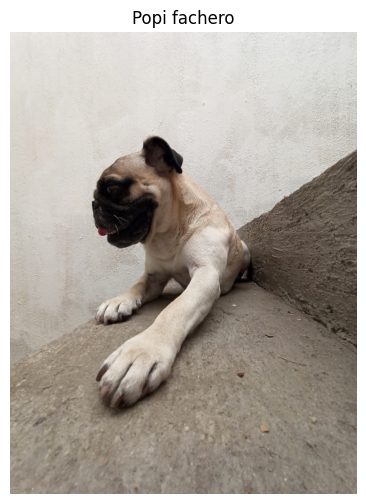

In [13]:
# 1. Definir la ruta del archivo (ajusta el nombre del archivo)
path = '/content/drive/MyDrive/Procesamiento Digital del Imágenes/Operaciones a nivel pixel/Popi_fachero.jpg'

# 2. Leer la imagen
# Nota: OpenCV lee las imágenes en formato BGR por defecto
popi_fachero = cv2.imread(path)

if popi_fachero is None:
    print("Error: No se pudo cargar la imagen. Verifica que la ruta sea correcta.")
else:
    # 3. Convertir de BGR a RGB para mostrarla correctamente con Matplotlib
    popi_fachero_rgb = cv2.cvtColor(popi_fachero, cv2.COLOR_BGR2RGB)

    # 4. Mostrar la imagen
    plt.figure(figsize=(8, 6))
    plt.imshow(popi_fachero_rgb)
    plt.title('Popi fachero')
    plt.axis('off')
    plt.show()

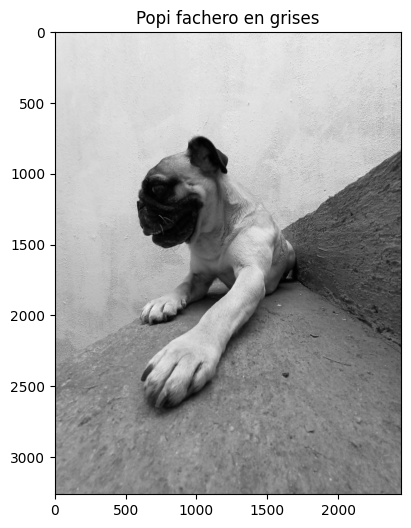

In [37]:
#convertimos la imagen a blanco y negro
popi_fachero_grises = cv2.cvtColor(popi_fachero_rgb, cv2.COLOR_BGR2GRAY)
# y la imprimimos para corroborar que se vea en esta tonalidad
plt.figure(figsize=(8, 6))
plt.imshow(popi_fachero_grises, cmap='gray')
plt.title('Popi fachero en grises')
# plt.axis('off')
plt.show()

## Histograma de la imagen

In [21]:
# Librerias:
import numpy as np

In [22]:
print(type(popi_fachero_grises)) # Vemos que es un array de numpy
print(popi_fachero_grises[0][1]) # se puede iterar como un array

<class 'numpy.ndarray'>
229


In [28]:
max, min = popi_fachero_grises.max(), popi_fachero_grises.min() # sacamos máximos y minimos de la imagen
# print(max, " " , min) 254  0

In [33]:
histograma = [0]*(max+1) # 254 + 1 ya que empieza en cero
# print(len(histograma))

In [41]:
for i in popi_fachero_grises: # recorremos cada fila
  for k in i: # recorremos cada columna
    histograma[k] = histograma[k] + 1 # Agregamos una cuenta al valor de la clase del histograma
print(histograma)

1
[658, 3039, 5599, 8105, 10274, 11551, 11575, 10810, 9998, 9293, 8753, 8872, 8433, 8409, 8160, 8108, 7601, 7273, 7002, 6779, 6724, 6451, 6424, 6177, 6264, 6059, 6209, 6391, 6544, 6831, 7121, 7072, 7310, 7616, 7705, 7901, 8053, 8198, 8255, 8477, 8710, 9163, 9569, 10039, 10641, 10752, 11292, 11465, 12078, 12675, 12920, 13235, 13511, 13713, 14236, 14395, 14882, 15421, 15578, 15956, 16081, 16434, 16943, 17520, 17668, 17944, 18750, 19462, 20073, 20494, 21030, 21686, 21737, 21947, 22420, 22171, 22026, 22283, 22125, 22413, 22400, 22250, 22397, 22136, 22332, 22697, 22535, 22642, 22550, 23082, 22855, 22548, 22155, 22131, 22046, 21964, 21828, 21988, 21824, 21864, 21887, 22140, 22260, 22802, 22883, 23289, 24204, 25387, 26560, 27382, 28440, 29580, 31441, 33503, 35703, 38313, 40909, 43330, 46204, 49566, 53066, 56563, 60403, 63121, 65981, 68132, 70755, 73550, 76610, 80271, 83689, 86661, 88768, 89817, 88881, 86024, 83167, 79570, 76164, 72491, 69416, 65125, 62683, 59862, 57514, 54581, 51142, 46210, 4

Text(0.5, 1.0, 'Histograma de la imagen Popi Fachero')

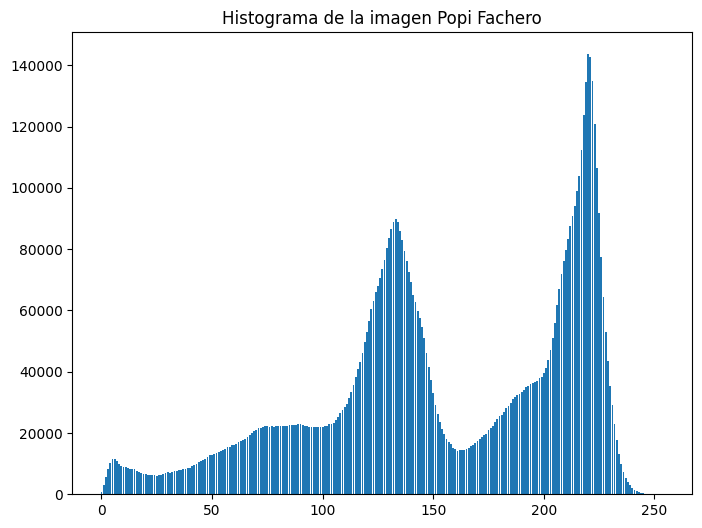

In [45]:
plt.figure(figsize=(8, 6))
# graficamos el histograma de frecuencias
plt.bar(range(len(histograma)), histograma)
plt.title('Histograma de la imagen Popi Fachero')

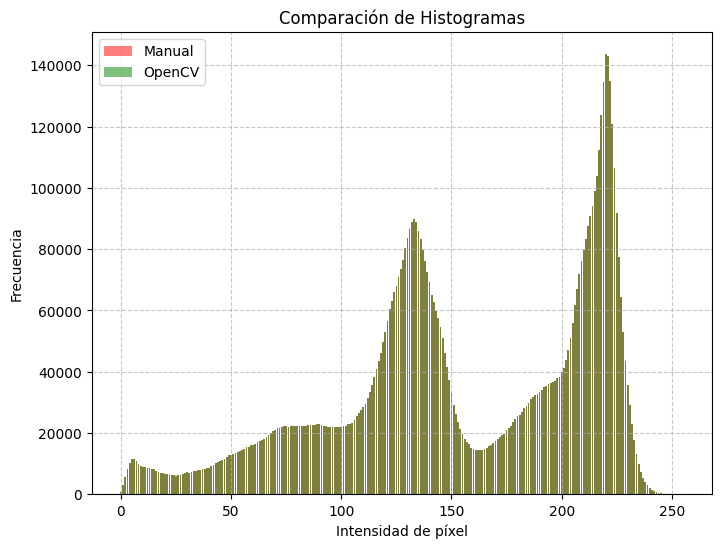

In [59]:
# Calcular el histograma con OpenCV
# cv2.calcHist(images, channels, mask, histSize, ranges)
hist_cv2 = cv2.calcHist([popi_fachero_grises], [0], None, [256], [0, 256])

# Corregimos el print: usamos 1 en lugar de 0 para la dimensión, o simplemente aplanamos
# print(hist_cv2.flatten())

# Graficar para comparar
plt.figure(figsize=(8, 6))
# histograma manual (rojo)
plt.bar(range(len(histograma)), histograma, color='r', alpha=0.5, label='Manual')
# histograma OpenCV (verde) - usamos .flatten() para convertir a 1D
plt.bar(range(256), hist_cv2.flatten(), color='g', alpha=0.5, label='OpenCV')

plt.title('Comparación de Histogramas')
plt.xlabel('Intensidad de píxel')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()